# **Portfolio:** Mario Casanova — Data Science & Analytics Portfolio
## **Case Study:** Exotic Options Valuation (Heston Stochastic Volatility)

---
*This notebook prices a path-dependent arithmetic Asian call under the Heston stochastic-volatility model, by Monte Carlo with Euler–Maruyama discretization, using antithetic variates for variance reduction. I don't assert the reduction; I measure it — against plain Monte Carlo at the same path budget, the antithetic estimator here delivers roughly 1.6× lower standard error, which is the same precision for about 2.5× fewer paths. The inputs are illustrative rather than calibrated to any market: the point is a clean, honest demonstration of the simulation scheme and the variance-reduction technique, not a production pricer.*

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import seaborn as sns
from scipy.stats import norm

plt.style.use('dark_background')
np.random.seed(42) # Strict reproducibility for sensitivity analysis

### 1. Stochastic Dynamics: Heston Model
The model assumes that the variance follows its own mean-reverting process (CIR Process):

$dS_t = r S_t dt + \sqrt{v_t} S_t dW_t^S$

$dv_t = \kappa (\theta - v_t) dt + \xi \sqrt{v_t} dW_t^v$

Where the Wiener processes $dW_t^S$ and $dW_t^v$ have correlation $\rho$.

In [2]:
def heston_paths(S0, v0, kappa, theta, xi, rho, r, T, M, N, antithetic=True):
    """
    Simulate N Heston paths over horizon T with M Euler-Maruyama steps.

    When ``antithetic=True`` (default) the N paths are generated as N/2 base
    draws plus their sign-flipped mirrors: for every Brownian increment Z we also
    simulate -Z. The two halves are negatively correlated, so pairing a path with
    its mirror cancels the odd part of the Monte-Carlo error and lowers the
    variance of the price estimate at no extra path cost. Columns 0..N/2-1 are the
    base paths and N/2..N-1 their mirrors (paired by offset N/2), a structure the
    estimator downstream relies on.
    """
    dt = T / M
    if antithetic:
        half = N // 2
        Zv_base = np.random.normal(0, 1, (M, half))
        Zsu_base = np.random.normal(0, 1, (M, half))
        Z_v = np.concatenate([Zv_base, -Zv_base], axis=1)
        Z_s_uncorr = np.concatenate([Zsu_base, -Zsu_base], axis=1)
    else:
        Z_v = np.random.normal(0, 1, (M, N))
        Z_s_uncorr = np.random.normal(0, 1, (M, N))
    # Correlated Brownian motions (leverage effect via rho)
    Z_s = rho * Z_v + np.sqrt(1 - rho**2) * Z_s_uncorr

    v = np.zeros((M + 1, N))
    v[0] = v0
    S = np.zeros((M + 1, N))
    S[0] = S0

    # Euler-Maruyama with full truncation on the CIR variance
    for t in range(1, M + 1):
        v[t] = np.maximum(0, v[t-1] + kappa * (theta - v[t-1]) * dt + xi * np.sqrt(v[t-1]) * np.sqrt(dt) * Z_v[t-1])
        S[t] = S[t-1] * np.exp((r - 0.5 * v[t-1]) * dt + np.sqrt(v[t-1]) * np.sqrt(dt) * Z_s[t-1])

    return S, v

# Model parameters
S0 = 100.0   # Spot
v0 = 0.04    # Initial Variance (20% Vol)
kappa = 2.0  # Reversion speed
theta = 0.04 # Long-term mean
xi = 0.3     # Vol-of-vol
rho = -0.7   # Leverage effect
r = 0.03     # Risk-free rate
T = 1.0      # Maturity (1 year)
M = 252      # Trading days
N = 50000    # Simulated paths (even -> N/2 antithetic pairs)

print(f"[*] Computing {N} antithetic paths under Heston...")
S_paths, v_paths = heston_paths(S0, v0, kappa, theta, xi, rho, r, T, M, N, antithetic=True)
print("[+] Simulation complete.")

[*] Computing 50000 antithetic paths under Heston...


[+] Simulation complete.


### 2. Empirical Valuation and Variance Reduction
This is a discrete arithmetic-average Asian call: path dependence rules out a closed form, so Monte Carlo is the only real option. I price it with the antithetic estimator (averaging each base path with its mirror before taking the sample variance), and the next cell quantifies the variance reduction against plain Monte Carlo at the same path budget.

In [3]:
K_strike = 100
asian_average = np.mean(S_paths, axis=0)                      # arithmetic average price per path
discounted_payoffs = np.exp(-r * T) * np.maximum(asian_average - K_strike, 0)

# Antithetic estimator: average each base path with its mirror BEFORE taking the
# sample variance. The N/2 paired averages are the i.i.d. unit of Monte-Carlo error.
half = N // 2
paired = 0.5 * (discounted_payoffs[:half] + discounted_payoffs[half:])
mc_price = paired.mean()
mc_std_error = paired.std(ddof=1) / np.sqrt(half)

print(f"Estimated Value (Asian Call, antithetic): ${mc_price:.4f}")
print(f"Standard Error (antithetic):              ±${mc_std_error:.4f}")

Estimated Value (Asian Call, antithetic): $5.2019
Standard Error (antithetic):              ±$0.0186


### Variance reduction check
Plain (independent) Monte Carlo at the same path count, for a like-for-like standard-error comparison. The reduction comes from the **negative correlation** between each path's payoff and its mirror's (printed below), which cancels much of the odd part of the Monte-Carlo error.

In [4]:
# Plain Monte Carlo at the same path budget, for a like-for-like comparison.
np.random.seed(42)
S_naive, _ = heston_paths(S0, v0, kappa, theta, xi, rho, r, T, M, N, antithetic=False)
dp_naive = np.exp(-r * T) * np.maximum(np.mean(S_naive, axis=0) - K_strike, 0)
se_naive = dp_naive.std(ddof=1) / np.sqrt(N)

corr_pair = np.corrcoef(discounted_payoffs[:half], discounted_payoffs[half:])[0, 1]
ratio = se_naive / mc_std_error

print(f"Naive MC:       price=${dp_naive.mean():.4f}    SE=±${se_naive:.4f}")
print(f"Antithetic MC:  price=${mc_price:.4f}    SE=±${mc_std_error:.4f}")
print(f"\ncorr(payoff, mirror payoff) = {corr_pair:.3f}   (negative -> the average's variance shrinks)")
print(f"Variance-reduction ratio (SE_naive / SE_antithetic): {ratio:.2f}x")
print(f"=> ~{ratio**2:.1f}x fewer paths for the same standard error")

Naive MC:       price=$5.2516    SE=±$0.0294
Antithetic MC:  price=$5.2019    SE=±$0.0186

corr(payoff, mirror payoff) = -0.598   (negative -> the average's variance shrinks)
Variance-reduction ratio (SE_naive / SE_antithetic): 1.58x
=> ~2.5x fewer paths for the same standard error


### 3. Stochastic Visualization (Trajectory Surface Isolation)

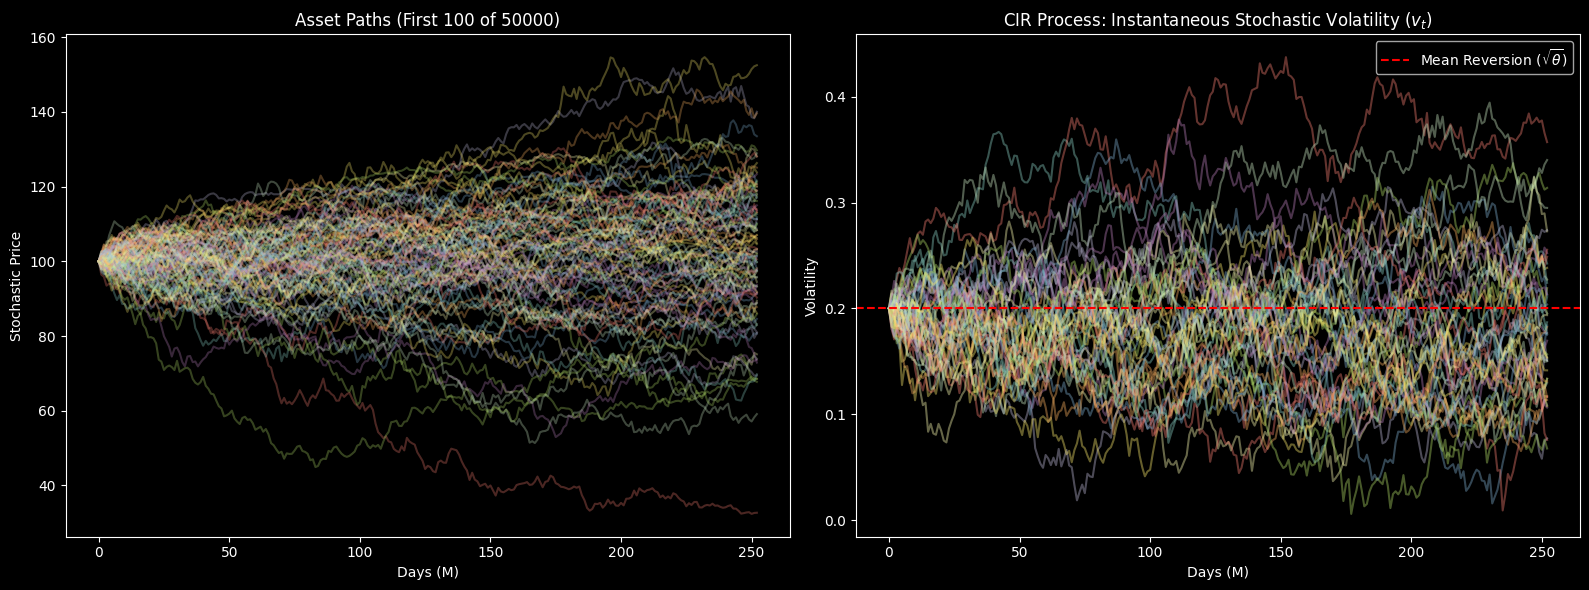

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot asset paths
ax1.plot(S_paths[:, :100], alpha=0.3, linewidth=1.5)
ax1.set_title(f'Asset Paths (First 100 of {N})', fontsize=12)
ax1.set_xlabel('Days (M)')
ax1.set_ylabel('Stochastic Price')

# Plot volatility paths showing mean reversion
v_paths_sqrt = np.sqrt(v_paths[:, :50])
ax2.plot(v_paths_sqrt, alpha=0.4, linewidth=1.5)
ax2.axhline(y=np.sqrt(theta), color='red', linestyle='--', label=r'Mean Reversion $(\sqrt{\theta})$')
ax2.set_title('CIR Process: Instantaneous Stochastic Volatility ($v_t$)', fontsize=12)
ax2.set_xlabel('Days (M)')
ax2.set_ylabel('Volatility')
ax2.legend()

plt.tight_layout()
plt.show()

### Synthesis
The antithetic estimator prices the Asian call at about \$5.20, standard error ±\$0.019 (roughly **1.6× tighter** than plain Monte Carlo at the same 50k-path budget), a precision that plain Monte Carlo would need about 2.5× more paths to reach, for free. The gain isn't a lucky seed; it has a mechanism. The leverage effect (ρ=−0.7) makes a path and its sign-flipped mirror strongly anti-correlated in payoff (about −0.6 here), so averaging the two cancels much of what would otherwise be noise.

This estimate still carries Euler–Maruyama discretization bias (M=252 steps) on top of Monte Carlo error, and the inputs are illustrative rather than calibrated to a market — I'd trust the mechanism demonstrated here well before I'd trust the price itself. Two extensions would tighten this further: a control variate built on the closed-form geometric-average Asian price, and Greeks (delta, vega) by finite differences under common random numbers, so the bump estimates don't inherit fresh Monte Carlo noise of their own.